In [7]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [8]:
# Load data and prepare X_train_5
# This assumes feature_engineering.ipynb has been run, or we recreate X_train_5 here

# Load the training data
df = pd.read_csv("../datasets/nrel_training_data.csv")
df_feat = df.drop(['County', 'full_timeseries_directory', 'full_timeseries_path'], axis=1)
X = df_feat.drop('isTurbine', axis=1)
y = df_feat['isTurbine']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data loaded: {X_train.shape[0]} training samples, {X_test.shape[0]} test samples")
print(f"Target distribution in training: {y_train.value_counts().to_dict()}")

Data loaded: 152688 training samples, 38172 test samples
Target distribution in training: {False: 94413, True: 58275}


In [9]:
# Recreate X_train_5 following the same steps from feature_engineering.ipynb
# We'll need to apply the same preprocessing steps

# For now, let's try to use a simpler approach - load from feature_engineering if available
# Otherwise, we'll need to recreate the preprocessing steps

# Let's check if we can import from the feature engineering notebook
# Since we can't directly import, we'll recreate the key steps needed for X_train_5

# Step 1: Select the features we need for X_train_5
# X_train_5: Base + numeric + State + new features
base_features = ['fraction_of_usable_area', 'capacity_factor']
numeric_wind = 'wind_speed'
numeric_capacity = 'capacity'
state_feature = 'State'

# For X_train_5, we need:
# - base_features: fraction_of_usable_area, capacity_factor
# - numeric: wind_speed, capacity
# - State (will be one-hot encoded)
# - new features: combined_wind_rescource, potential_with_constraints

# Create new features
X_train['combined_wind_rescource'] = X_train['wind_speed'] * X_train['capacity_factor']
X_train['potential_with_constraints'] = X_train['capacity'] * X_train['fraction_of_usable_area']

# Select features for X_train_5
X_train_5 = X_train[base_features + [numeric_wind, numeric_capacity, state_feature, 
                                      'combined_wind_rescource', 'potential_with_constraints']].copy()

# One-hot encode State
state_dummies = pd.get_dummies(X_train_5['State'], prefix='State', drop_first=False)
X_train_5 = X_train_5.drop(columns=[state_feature])
X_train_5 = pd.concat([X_train_5, state_dummies], axis=1)

# Also prepare test set with same features
X_test_prep = X_test[base_features + [numeric_wind, numeric_capacity, state_feature]].copy()
X_test_prep['combined_wind_rescource'] = X_test['wind_speed'] * X_test['capacity_factor']
X_test_prep['potential_with_constraints'] = X_test['capacity'] * X_test['fraction_of_usable_area']

# One-hot encode State for test set (align columns with training set)
state_dummies_test = pd.get_dummies(X_test_prep['State'], prefix='State', drop_first=False)
X_test_prep = X_test_prep.drop(columns=[state_feature])
X_test_prep = pd.concat([X_test_prep, state_dummies_test], axis=1)

# Align test columns with training columns (add missing, remove extra)
missing_cols = set(X_train_5.columns) - set(X_test_prep.columns)
for col in missing_cols:
    X_test_prep[col] = 0

extra_cols = set(X_test_prep.columns) - set(X_train_5.columns)
X_test_prep = X_test_prep.drop(columns=extra_cols)

# Ensure same column order
X_test_prep = X_test_prep[X_train_5.columns]

print(f"X_train_5 shape: {X_train_5.shape}")
print(f"X_test shape: {X_test_prep.shape}")
print(f"Features: {list(X_train_5.columns[:10])}... (showing first 10)")

X_train_5 shape: (152688, 56)
X_test shape: (38172, 56)
Features: ['fraction_of_usable_area', 'capacity_factor', 'wind_speed', 'capacity', 'combined_wind_rescource', 'potential_with_constraints', 'State_Alabama', 'State_Arizona', 'State_Arkansas', 'State_California']... (showing first 10)


In [10]:
# Calculate scale_pos_weight = #negative / #positive
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
scale_pos_weight = negative_count / positive_count

print(f"Class distribution:")
print(f"  Negative (0): {negative_count}")
print(f"  Positive (1): {positive_count}")
print(f"  scale_pos_weight: {scale_pos_weight:.4f}")

Class distribution:
  Negative (0): 94413
  Positive (1): 58275
  scale_pos_weight: 1.6201


In [11]:
# Step 1: Train a baseline XGBoost model first
print("=" * 80)
print("STEP 1: Training Baseline XGBoost Model")
print("=" * 80)

baseline_model = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    objective='binary:logistic',
    scale_pos_weight=scale_pos_weight
)

print("Training baseline model...")
baseline_model.fit(X_train_5, y_train)

# Evaluate baseline model
y_pred_baseline = baseline_model.predict(X_test_prep)
y_pred_proba_baseline = baseline_model.predict_proba(X_test_prep)[:, 1]

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline)
baseline_roc_auc = roc_auc_score(y_test, y_pred_proba_baseline)

print("\nBaseline Model Performance:")
print(f"  Accuracy:  {baseline_accuracy:.4f}")
print(f"  F1 Score:  {baseline_f1:.4f}")
print(f"  ROC-AUC:   {baseline_roc_auc:.4f}")

print("\nBaseline Model Parameters:")
print(f"  max_depth: default ({baseline_model.max_depth})")
print(f"  learning_rate: default ({baseline_model.learning_rate})")
print(f"  n_estimators: default ({baseline_model.n_estimators})")
print(f"  subsample: default ({baseline_model.subsample})")
print(f"  colsample_bytree: default ({baseline_model.colsample_bytree})")
print(f"  scale_pos_weight: {scale_pos_weight:.4f}")

STEP 1: Training Baseline XGBoost Model
Training baseline model...

Baseline Model Performance:
  Accuracy:  0.8449
  F1 Score:  0.8162
  ROC-AUC:   0.9282

Baseline Model Parameters:
  max_depth: default (None)
  learning_rate: default (None)
  n_estimators: default (None)
  subsample: default (None)
  colsample_bytree: default (None)
  scale_pos_weight: 1.6201


In [12]:
# Step 2: Hyperparameter tuning with GridSearchCV
print("=" * 80)
print("STEP 2: Hyperparameter Tuning with GridSearchCV")
print("=" * 80)

# Define the parameter grid
# Note: learning_rate and n_estimators are tested as specific pairs: (0.1, 300) and (0.05, 500)
# We'll create a list of parameter dictionaries where each dict represents one combination to test
from sklearn.model_selection import ParameterGrid

# First, create the base parameter combinations
base_params = {
    'max_depth': [4, 6, 8],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

# Generate base combinations
base_combinations = list(ParameterGrid(base_params))

# Now create the full parameter list with the specific learning_rate + n_estimators pairs
# Note: GridSearchCV requires all values to be in lists, even single values
param_grid_list = []
for base_combo in base_combinations:
    # Add (0.1, 300) combination - wrap all values in lists
    param_grid_list.append({
        'max_depth': [base_combo['max_depth']],
        'subsample': [base_combo['subsample']],
        'colsample_bytree': [base_combo['colsample_bytree']],
        'learning_rate': [0.1],
        'n_estimators': [300],
        'scale_pos_weight': [scale_pos_weight]
    })
    # Add (0.05, 500) combination - wrap all values in lists
    param_grid_list.append({
        'max_depth': [base_combo['max_depth']],
        'subsample': [base_combo['subsample']],
        'colsample_bytree': [base_combo['colsample_bytree']],
        'learning_rate': [0.05],
        'n_estimators': [500],
        'scale_pos_weight': [scale_pos_weight]
    })

# Create base XGBoost classifier
xgb_base = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    objective='binary:logistic'
)

# Calculate total combinations
total_combinations = len(param_grid_list)
print(f"\nCreating GridSearchCV...")
print(f"Total parameter combinations: {total_combinations}")
print(f"  max_depth: [4, 6, 8] = 3 values")
print(f"  learning_rate + n_estimators pairs: (0.1, 300), (0.05, 500) = 2 pairs")
print(f"  subsample: [0.7, 0.8, 1.0] = 3 values")
print(f"  colsample_bytree: [0.7, 0.8, 1.0] = 3 values")
print(f"  scale_pos_weight: {scale_pos_weight:.4f} (fixed)")
print(f"  Total: 3 × 2 × 3 × 3 = {total_combinations} combinations")

# Create GridSearchCV
# Using ROC-AUC as scoring metric since it's good for imbalanced datasets
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_list,
    scoring='roc_auc',
    cv=5,  # 5-fold cross-validation
    n_jobs=-1,  # Use all available cores
    verbose=1,
    return_train_score=True
)

print("\nStarting grid search (this may take a while)...")
print("Testing parameter combinations with:")
print("  - max_depth: [4, 6, 8]")
print("  - learning_rate + n_estimators pairs: (0.1, 300), (0.05, 500)")
print("  - subsample: [0.7, 0.8, 1.0]")
print("  - colsample_bytree: [0.7, 0.8, 1.0]")
print(f"  - scale_pos_weight: {scale_pos_weight:.4f} (fixed)")

# Fit the grid search
grid_search.fit(X_train_5, y_train)

print("\nGrid search completed!")

STEP 2: Hyperparameter Tuning with GridSearchCV

Creating GridSearchCV...
Total parameter combinations: 54
  max_depth: [4, 6, 8] = 3 values
  learning_rate + n_estimators pairs: (0.1, 300), (0.05, 500) = 2 pairs
  subsample: [0.7, 0.8, 1.0] = 3 values
  colsample_bytree: [0.7, 0.8, 1.0] = 3 values
  scale_pos_weight: 1.6201 (fixed)
  Total: 3 × 2 × 3 × 3 = 54 combinations

Starting grid search (this may take a while)...
Testing parameter combinations with:
  - max_depth: [4, 6, 8]
  - learning_rate + n_estimators pairs: (0.1, 300), (0.05, 500)
  - subsample: [0.7, 0.8, 1.0]
  - colsample_bytree: [0.7, 0.8, 1.0]
  - scale_pos_weight: 1.6201 (fixed)
Fitting 5 folds for each of 54 candidates, totalling 270 fits

Grid search completed!


In [13]:
# Display results
print("=" * 80)
print("GRID SEARCH RESULTS")
print("=" * 80)

print(f"\nBest Parameters:")
best_params = grid_search.best_params_
for param, value in best_params.items():
    print(f"  {param}: {value}")

print(f"\nBest Cross-Validation Score (ROC-AUC): {grid_search.best_score_:.4f}")

# Get the best model
best_model = grid_search.best_estimator_

# Evaluate best model on test set
y_pred_best = best_model.predict(X_test_prep)
y_pred_proba_best = best_model.predict_proba(X_test_prep)[:, 1]

best_accuracy = accuracy_score(y_test, y_pred_best)
best_f1 = f1_score(y_test, y_pred_best)
best_roc_auc = roc_auc_score(y_test, y_pred_proba_best)

print("\nBest Model Performance on Test Set:")
print(f"  Accuracy:  {best_accuracy:.4f}")
print(f"  F1 Score:  {best_f1:.4f}")
print(f"  ROC-AUC:   {best_roc_auc:.4f}")

print("\n" + "=" * 80)
print("COMPARISON: Baseline vs Tuned Model")
print("=" * 80)
print(f"{'Metric':<15} {'Baseline':<12} {'Tuned':<12} {'Improvement':<12}")
print("-" * 80)
print(f"{'Accuracy':<15} {baseline_accuracy:<12.4f} {best_accuracy:<12.4f} {best_accuracy - baseline_accuracy:+.4f}")
print(f"{'F1 Score':<15} {baseline_f1:<12.4f} {best_f1:<12.4f} {best_f1 - baseline_f1:+.4f}")
print(f"{'ROC-AUC':<15} {baseline_roc_auc:<12.4f} {best_roc_auc:<12.4f} {best_roc_auc - baseline_roc_auc:+.4f}")

GRID SEARCH RESULTS

Best Parameters:
  colsample_bytree: 1.0
  learning_rate: 0.1
  max_depth: 8
  n_estimators: 300
  scale_pos_weight: 1.6201287001287001
  subsample: 0.7

Best Cross-Validation Score (ROC-AUC): 0.9522

Best Model Performance on Test Set:
  Accuracy:  0.8783
  F1 Score:  0.8537
  ROC-AUC:   0.9545

COMPARISON: Baseline vs Tuned Model
Metric          Baseline     Tuned        Improvement 
--------------------------------------------------------------------------------
Accuracy        0.8449       0.8783       +0.0335
F1 Score        0.8162       0.8537       +0.0375
ROC-AUC         0.9282       0.9545       +0.0263


In [14]:
# Display top 10 parameter combinations
print("\n" + "=" * 80)
print("TOP 10 PARAMETER COMBINATIONS")
print("=" * 80)

# Get results as DataFrame
results_df = pd.DataFrame(grid_search.cv_results_)

# Sort by mean test score
top_results = results_df.nlargest(10, 'mean_test_score')[
    ['param_max_depth', 'param_learning_rate', 'param_n_estimators', 
     'param_subsample', 'param_colsample_bytree', 'mean_test_score', 'std_test_score']
]

print("\nTop 10 combinations (sorted by mean_test_score):")
for idx, row in top_results.iterrows():
    print(f"\nRank {len(top_results) - list(top_results.index).index(idx)}:")
    print(f"  max_depth: {row['param_max_depth']}")
    print(f"  learning_rate: {row['param_learning_rate']}")
    print(f"  n_estimators: {row['param_n_estimators']}")
    print(f"  subsample: {row['param_subsample']}")
    print(f"  colsample_bytree: {row['param_colsample_bytree']}")
    print(f"  Mean CV Score: {row['mean_test_score']:.4f} (+/- {row['std_test_score']:.4f})")


TOP 10 PARAMETER COMBINATIONS

Top 10 combinations (sorted by mean_test_score):

Rank 10:
  max_depth: 8.0
  learning_rate: 0.1
  n_estimators: 300.0
  subsample: 0.7
  colsample_bytree: 1.0
  Mean CV Score: 0.9522 (+/- 0.0024)

Rank 9:
  max_depth: 8.0
  learning_rate: 0.1
  n_estimators: 300.0
  subsample: 0.8
  colsample_bytree: 1.0
  Mean CV Score: 0.9517 (+/- 0.0021)

Rank 8:
  max_depth: 8.0
  learning_rate: 0.1
  n_estimators: 300.0
  subsample: 0.7
  colsample_bytree: 0.8
  Mean CV Score: 0.9506 (+/- 0.0023)

Rank 7:
  max_depth: 8.0
  learning_rate: 0.1
  n_estimators: 300.0
  subsample: 0.8
  colsample_bytree: 0.8
  Mean CV Score: 0.9504 (+/- 0.0022)

Rank 6:
  max_depth: 8.0
  learning_rate: 0.1
  n_estimators: 300.0
  subsample: 0.7
  colsample_bytree: 0.7
  Mean CV Score: 0.9498 (+/- 0.0022)

Rank 5:
  max_depth: 8.0
  learning_rate: 0.1
  n_estimators: 300.0
  subsample: 0.8
  colsample_bytree: 0.7
  Mean CV Score: 0.9494 (+/- 0.0021)

Rank 4:
  max_depth: 8.0
  learning

In [ ]:
# Save the best model and results
print("\n" + "=" * 80)
print("SAVING MODEL AND RESULTS")
print("=" * 80)

# Save the best model
model_filename = "xgboost_tuned_wind_model.pkl"
joblib.dump(best_model, model_filename)
print(f"Best model saved to: {model_filename}")

# Save model parameters
model_params = {
    "model_type": "XGBoost (Hyperparameter Tuned)",
    "best_parameters": best_params,
    "scale_pos_weight": float(scale_pos_weight),
    "n_features": X_train_5.shape[1],
    "n_samples": X_train_5.shape[0]
}

params_filename = "xgboost_tuned_model_params.json"
with open(params_filename, "w") as f:
    json.dump(model_params, f, indent=4)
print(f"Model parameters saved to: {params_filename}")

# Save metrics
metrics = {
    "model": "xgboost_tuned",
    "baseline_metrics": {
        "accuracy": float(baseline_accuracy),
        "f1_score": float(baseline_f1),
        "roc_auc": float(baseline_roc_auc)
    },
    "tuned_metrics": {
        "accuracy": float(best_accuracy),
        "f1_score": float(best_f1),
        "roc_auc": float(best_roc_auc)
    },
    "best_cv_score": float(grid_search.best_score_),
    "improvement": {
        "accuracy": float(best_accuracy - baseline_accuracy),
        "f1_score": float(best_f1 - baseline_f1),
        "roc_auc": float(best_roc_auc - baseline_roc_auc)
    },
    "classification_report": classification_report(y_test, y_pred_best, digits=3, output_dict=True)
}

metrics_filename = "xgboost_tuned_model_metrics.json"
with open(metrics_filename, "w") as f:
    json.dump(metrics, f, indent=4)
print(f"Model metrics saved to: {metrics_filename}")

# Save confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
print(f"\nConfusion Matrix:")
print(cm)
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_best, digits=3))


SAVING MODEL AND RESULTS
Best model saved to: xgboost_tuned_wind_model.pkl
Model parameters saved to: xgboost_tuned_model_params.json
Model metrics saved to: xgboost_tuned_model_metrics.json

Confusion Matrix:
[[19980  3818]
 [  826 13548]]

Classification Report:
              precision    recall  f1-score   support

       False      0.960     0.840     0.896     23798
        True      0.780     0.943     0.854     14374

    accuracy                          0.878     38172
   macro avg      0.870     0.891     0.875     38172
weighted avg      0.892     0.878     0.880     38172



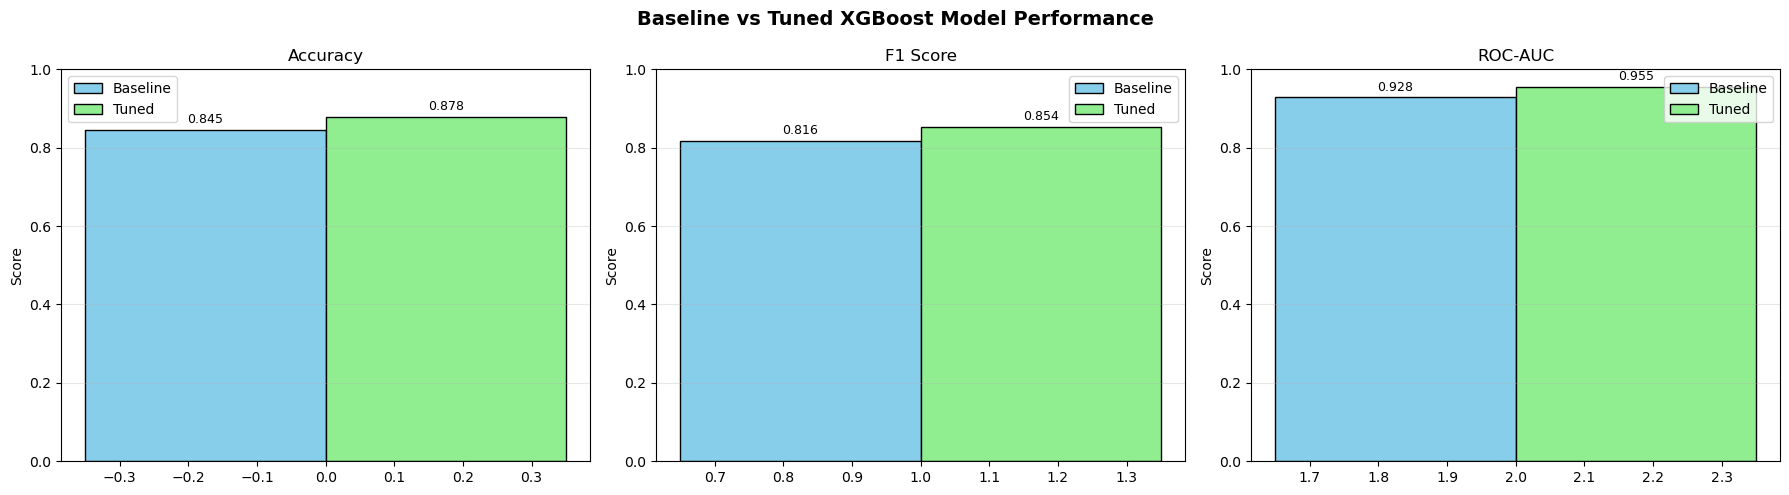


Visualization saved to: xgboost_tuning_comparison.png


In [ ]:
# Optional: Visualize results
import matplotlib.pyplot as plt

# Create a comparison plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_names = ['Accuracy', 'F1 Score', 'ROC-AUC']
baseline_values = [baseline_accuracy, baseline_f1, baseline_roc_auc]
tuned_values = [best_accuracy, best_f1, best_roc_auc]

x = np.arange(len(metrics_names))
width = 0.35

for i, ax in enumerate(axes):
    bars1 = ax.bar(x[i] - width/2, baseline_values[i], width, label='Baseline', color='skyblue', edgecolor='black')
    bars2 = ax.bar(x[i] + width/2, tuned_values[i], width, label='Tuned', color='lightgreen', edgecolor='black')
    
    ax.set_ylabel('Score')
    ax.set_title(metrics_names[i])
    ax.set_ylim([0, 1])
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    ax.text(x[i] - width/2, baseline_values[i] + 0.01, f'{baseline_values[i]:.3f}', 
            ha='center', va='bottom', fontsize=9)
    ax.text(x[i] + width/2, tuned_values[i] + 0.01, f'{tuned_values[i]:.3f}', 
            ha='center', va='bottom', fontsize=9)

plt.suptitle('Baseline vs Tuned XGBoost Model Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('xgboost_tuning_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualization saved to: xgboost_tuning_comparison.png")